In [11]:
import numpy as np
import scipy as sp
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import scienceplots

from matplotlib.font_manager import FontProperties
from qutip import *

plt.style.use('science')

h = 6.62607015e-34
hbar = 1.054571817e-34
e = 1.60217663e-19

Aharonov-Casher modulation in split fluxonium circuit, demonstrating using fluxon

In [12]:
# parameters

L = 400e-9   # superinductance
Cj = 5e-15   # junction capacitance
Cp = 3e-15   # superinductor capacitance
Ccp = 0e-15   # probe-resonator coupling capacitance

phi0 = h / (2 * e)  # flux quantum

Ej = 10  # josephson energy
Ec = e**2 / (2 * (Cj + Ccp))  # charging energy
El = phi0**2 / (4 * np.pi**2 * L)   # inductive energy
Ecl = e**2 / (2 * Cp)  # superinductor charging energy

Ec = Ec * 1e-9 / h
El = El * 1e-9 / h

ng_vals = [0.0, 0.5]  # CPB offset charge values
flux_vals = np.linspace(-1.0, 1.0, 201)  # flux values, in units of flux quantum

m = 5  # maximum number of fluxons

print('Ej = ', Ej)
print('Ec = ', Ec)
print('El = ', El)

Ej =  10
Ec =  3.874045845587911
El =  0.40865378405744596


In [13]:
# fluxon tunneling amplitude
S0 = np.sqrt(8 * Ej / Ec)
A = 32 * np.sqrt(Ej * Ec / np.pi) * (0.5 * Ej / Ec)**0.25
t0 = A * np.exp(-S0)

# hamiltonian in fluxon number basis
def get_hamiltonian(ng, phi):
    Hi = np.diag(0.5 * El * (2 * np.pi * np.arange(-m, m+1) - 2 * np.pi * phi) ** 2)    # inductive, diagnoal terms
    
    upper_diag = np.diag(np.ones(2 * m), 1)
    lower_diag = np.diag(np.ones(2 * m), -1)
    t = 2 * t0 * np.cos(np.pi * ng)    # tunneling amplitude, dependent on offset charge due to AC effect
    Ht = -t * (upper_diag + lower_diag)    # tunneling, off-diagnoal terms

    H = Hi + Ht
    
    return Qobj(H)

In [14]:
# spectrum and frequency, varying flux

def get_spectrum_varying_flux(ng):
    energy_vals_varying_flux = []
    freq_vals_varying_flux = []
    
    for phi in flux_vals:
        H = get_hamiltonian(ng, phi)
        eigv = H.eigenenergies()    # eigenenergies
        freq = eigv[1] - eigv[0]     # first transition energy
        
        energy_vals_varying_flux.append(eigv)
        freq_vals_varying_flux.append(freq)
        
    return np.array(energy_vals_varying_flux), np.array(freq_vals_varying_flux)

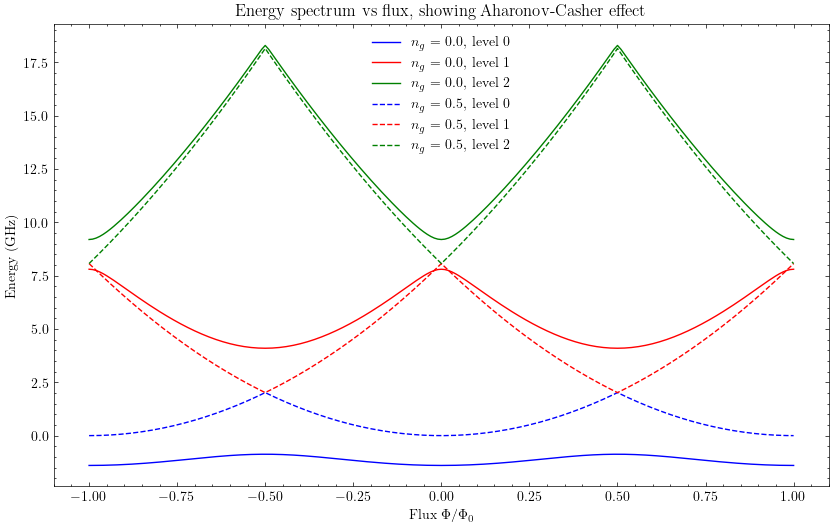

In [15]:
# plot spectrum
# only considering single fluxon tunneling between m & m+1
plt.figure(figsize=(10, 6))

for ng in ng_vals:
    energy, freq = get_spectrum_varying_flux(ng)
    label = f"$n_g$ = {ng}"
    for i, color in zip(range(3), ['b', 'r', 'g']):
        plt.plot(flux_vals, energy[:, i], color=color, linestyle='-' if ng==0 else '--', label=f'{label}, level {i}')

plt.title("Energy spectrum vs flux, showing Aharonov-Casher effect")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Energy (GHz)")
plt.legend()
plt.show()

# ng=0, fluxon tunneling, level repulsion and coupled states between m & m+1
# ng=0.5, fluxon tunneling suppressed, level crossing

Same plot as Bell's paper, working in fluxon number basis rather than charge/phase basis.

Single fluxon tunneling exists, tunneling amplitude given by WKB approximation: $t_0=32E_c\sqrt{\frac{2}{\pi}}(\frac{E_j}{2E_c})^{\frac{3}{4}}e^{-\sqrt{\frac{8E_j}{E_c}}}$.

For single junction shunted by superinductor, Aharonov–Casher effect adds a topological phase to each clockwise or counterclockwise tunneling (instanton/phase-slip) path so that paths interfere. Tunneling amplitude is modified to: $t=t_0(e^{i\pi n_g}+e^{-i\pi n_g})=2t_0\cos(\pi n_g)$.

Induced gate charge: $n_g=\frac{Q_g}{2e}$.

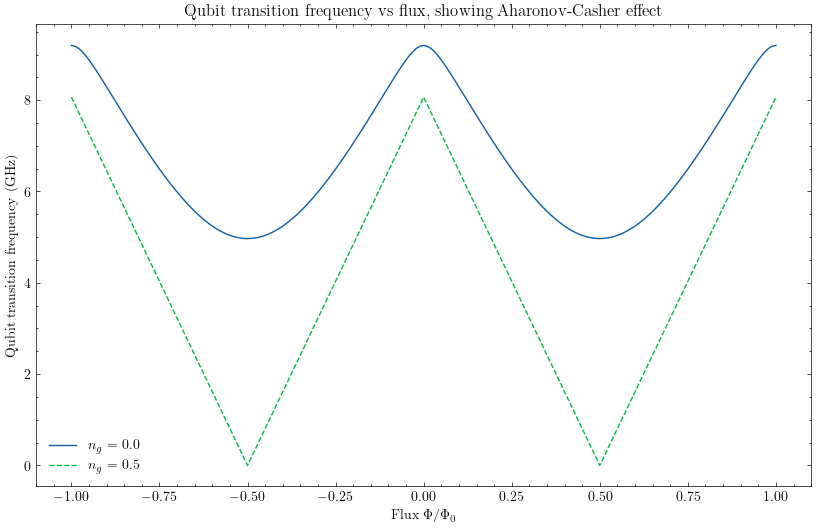

In [16]:
# frequency varying flux
plt.figure(figsize=(10, 6))

for ng in ng_vals:
    energy, freq = get_spectrum_varying_flux(ng)
    label = f"$n_g$ = {ng}"
    plt.plot(flux_vals, freq, linestyle='-' if ng==0 else '--', label=f'{label}')

plt.title("Qubit transition frequency vs flux, showing Aharonov-Casher effect")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Qubit transition frequency (GHz)")
plt.legend()
plt.show()

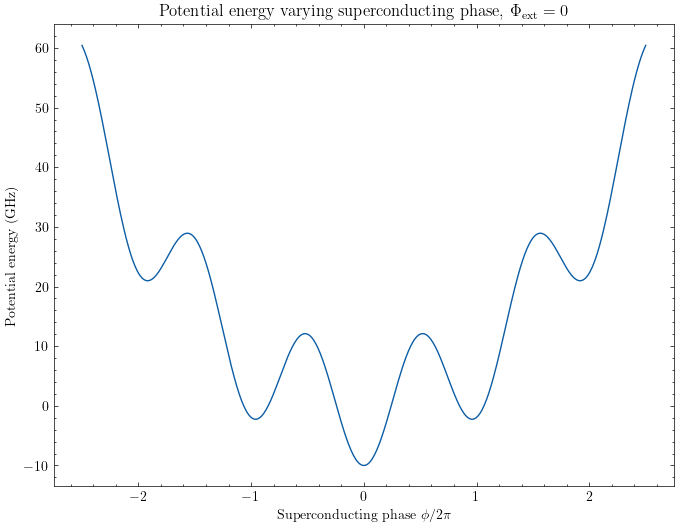

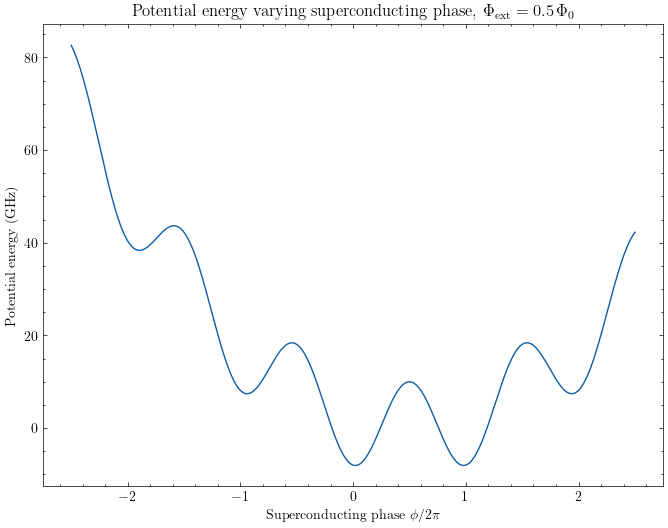

In [78]:
# potential varying superconducting phase (josephson junction)
def get_potential(phi, phi_ext, Ej, El):
    return 0.5 * El * (2 * np.pi * (phi - phi_ext))**2 - Ej * np.cos(2 * np.pi * phi)

phi_list_2 = np.linspace(-2.5, 2.5, 500)

# two external flux cases, phi_ext=0 and phi_ext=0.5
phi_exts = {
    r"$\Phi_\text{ext} = 0$": 0.0,
    r"$\Phi_\text{ext} = 0.5\,\Phi_0$": 0.5
}

# plot each case
for label, phi_ext in phi_exts.items():
    V = get_potential(phi_list_2, phi_ext, Ej, El)

    plt.figure(figsize=(8, 6))
    plt.plot(phi_list_2, V)
    plt.xlabel(r"Superconducting phase $\phi / 2\pi$")
    plt.ylabel("Potential energy (GHz)")
    plt.title(rf"Potential energy varying superconducting phase, {label}")
    plt.show()

When fluxons circling the loop, superconducting phase winds by $2\pi$. Fluxon number and superconducting phase relation: $\phi=2\pi m$.

External flux $\Phi=0$, fluxon states $m=\pm 1$ occupy degenerate minima symmetrically placed around state $m=0$. Phase slips of $4\pi$.

External flux $\Phi=0.5\Phi_0$, degenerate double well for fluxons states $m=0$ and $m=1$. Phase slips of $2\pi$.

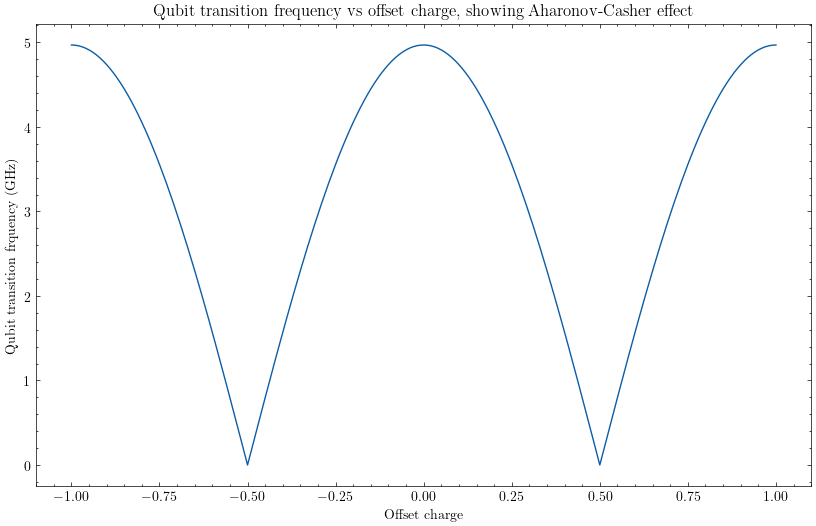

In [17]:
# frequency varying offset charge, flux kept at phi=0.5
ng_list = np.linspace(-1, 1, 201)

energy_vals_varying_ng = []
freq_vals_varying_ng = []

plt.figure(figsize=(10, 6))

for ng in ng_list:
    H = get_hamiltonian(ng, 0.5)
    eigv = H.eigenenergies()    # eigenenergies
    freq = eigv[1] - eigv[0]    # qubit transition frequency
    energy_vals_varying_ng.append(eigv)
    freq_vals_varying_ng.append(freq)

plt.plot(ng_list, freq_vals_varying_ng)

plt.title("Qubit transition frequency vs offset charge, showing Aharonov-Casher effect")
plt.xlabel("Offset charge")
plt.ylabel("Qubit transition frquency (GHz)")
plt.show()

When ng=0.5 (charge frustration), fluxon tunneling is suppressed by destructive AC effect, which results in vanishing coupling between states m & m+1 and disappearance of avoided crossing.

When ng=0 (away from charge frustration), fluxon tunneling between states m & m+1 is present, leading to energy level repulsion (avoided crossing).

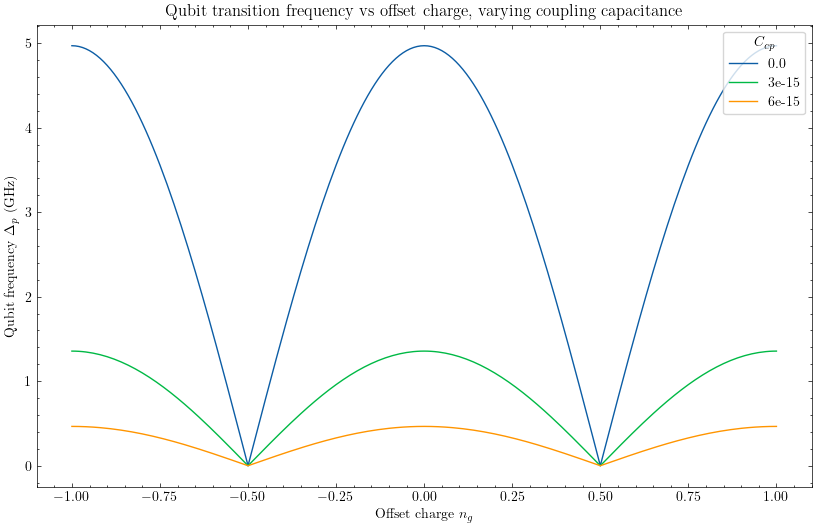

In [19]:
# frequency varying offset charge and coupling capacitance Ccp
Ccp_list = [0e-15, 3e-15, 6e-15]
freq_list_ng_varying_Ccp = {}

def get_hamiltonian_Ccp(ng, Ccp):
    # charging energy
    Ec = e**2 / (2 * (Cj + Ccp))
    Ec = Ec * 1e-9 / h

    # fluxon tunneling amplitude
    S0 = np.sqrt(8 * Ej / Ec)
    A = 32 * np.sqrt(Ej * Ec / np.pi) * (0.5 * Ej / Ec)**0.25
    t0 = A * np.exp(-S0)

    # hamiltonian
    Hi = np.diag(0.5 * El * (2 * np.pi * np.arange(-m, m+1) - 2 * np.pi * 0.5) ** 2)    # inductive, diagnoal terms
    upper_diag = np.diag(np.ones(2 * m), 1)
    lower_diag = np.diag(np.ones(2 * m), -1)
    t = 2 * t0 * np.cos(np.pi * ng)    # tunneling amplitude, dependent on offset charge due to AC effect
    Ht = -t * (upper_diag + lower_diag)    # tunneling, off-diagnoal terms
    H = Hi + Ht
    return Qobj(H)


for Ccp in Ccp_list: 
    freq_list_ng_varying_Ccp[Ccp] = []

    for ng in ng_list:
        H = get_hamiltonian_Ccp(ng, Ccp)
        eigv = H.eigenenergies()    # eigenenergies
        freq = eigv[1] - eigv[0]    # qubit transition frequency
        freq_list_ng_varying_Ccp[Ccp].append(freq)

plt.figure(figsize=(10,6))

plt.xlabel("Offset charge $n_g$")
plt.ylabel("Qubit frequency $\\Delta_p$ (GHz)")
plt.title("Qubit transition frequency vs offset charge, varying coupling capacitance")

for Ccp in freq_list_ng_varying_Ccp.keys():
    plt.plot(ng_list, freq_list_ng_varying_Ccp[Ccp], label=Ccp)

plt.legend(title='$C_{cp}$', loc='upper right', frameon=True)
plt.show()

Exactly the same plot as the flux qubit one, qubit gap decreases as coupling capacitance increases.

At $n_g=\pm 0.5$, qubit gap vanishes for all coupling capacitances

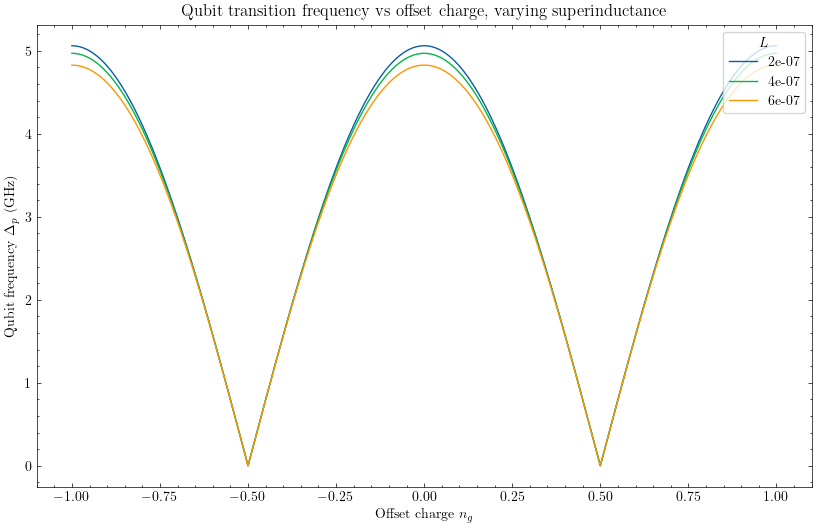

In [24]:
# frequency varying offset charge and superinductance L
L_list = [200e-9, 400e-9, 600e-9]
freq_list_ng_varying_L = {}

def get_hamiltonian_L(ng, L):
    # inductive energy
    El = phi0**2 / (4 * np.pi**2 * L)
    El = El * 1e-9 / h

    # fluxon tunneling amplitude
    S0 = np.sqrt(8 * Ej / Ec)
    A = 32 * np.sqrt(Ej * Ec / np.pi) * (0.5 * Ej / Ec)**0.25
    t0 = A * np.exp(-S0)

    # hamiltonian
    Hi = np.diag(0.5 * El * (2 * np.pi * np.arange(-m, m+1) - 2 * np.pi * 0.5) ** 2)    # inductive, diagnoal terms
    upper_diag = np.diag(np.ones(2 * m), 1)
    lower_diag = np.diag(np.ones(2 * m), -1)
    t = 2 * t0 * np.cos(np.pi * ng)    # tunneling amplitude, dependent on offset charge due to AC effect
    Ht = -t * (upper_diag + lower_diag)    # tunneling, off-diagnoal terms
    H = Hi + Ht
    return Qobj(H)


for L in L_list: 
    freq_list_ng_varying_L[L] = []

    for ng in ng_list:
        H = get_hamiltonian_L(ng, L)
        eigv = H.eigenenergies()    # eigenenergies
        freq = eigv[1] - eigv[0]    # qubit transition frequency
        freq_list_ng_varying_L[L].append(freq)

plt.figure(figsize=(10,6))

plt.xlabel("Offset charge $n_g$")
plt.ylabel("Qubit frequency $\\Delta_p$ (GHz)")
plt.title("Qubit transition frequency vs offset charge, varying superinductance")

for L in freq_list_ng_varying_L.keys():
    plt.plot(ng_list, freq_list_ng_varying_L[L], label=L)

plt.legend(title='$L$', loc='upper right', frameon=True)
plt.show()

t1_pref =  1.27295841518731 t2_pref =  1.4851553847217738


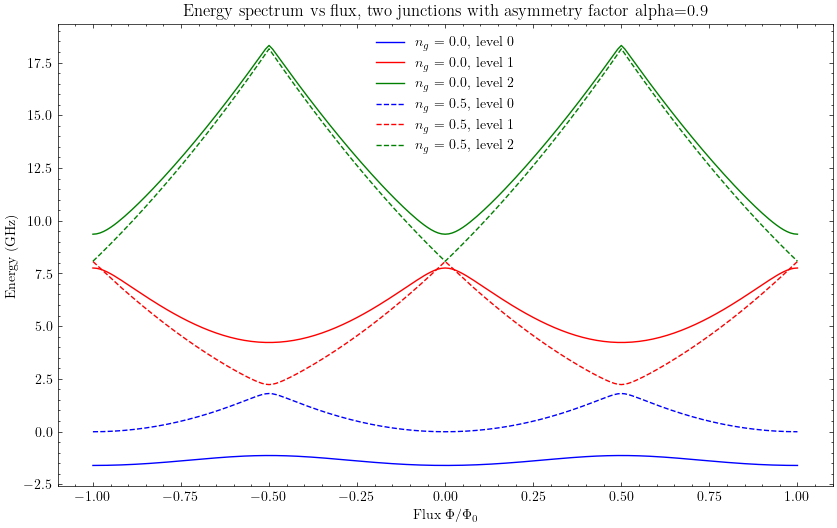

In [60]:
# replace with two junctions and introduce asymmetry between the junctions
# spectrum varying offset charge and asymmetry factor alpha

# josephson energies, an example when alpha=0.9
Ej1 = 10.0
alpha = 0.9
Ej2 = alpha * Ej1

ng_vals = [0.0, 0.5]
flux_vals = np.linspace(-1.0, 1.0, 201)

# tunneling amplitudes from wkb approximation
def get_tunneling_amplitude(Ej, Ec):
    S0 = np.sqrt(8.0 * Ej / Ec)
    A = 32.0 * np.sqrt(Ej * Ec / np.pi) * (0.5 * Ej / Ec) ** 0.25
    return A * np.exp(-S0)

t1_pref = get_tunneling_amplitude(Ej1, Ec)
t2_pref = get_tunneling_amplitude(Ej2, Ec)
print("t1_pref = ", t1_pref, "t2_pref = ", t2_pref)

# hamiltonian, varying aysmmetry factor (tunneling amplitude)
def get_hamiltonian_alpha(t1, t2, ng, phi):
    Hi = np.diag(0.5 * El * (2 * np.pi * np.arange(-m, m+1) - 2 * np.pi * phi) ** 2)    # inductive, diagnoal terms

    upper_diag = np.diag(np.ones(2 * m), 1)
    lower_diag = np.diag(np.ones(2 * m), -1)
    
    # fluxons acquire phases ±π*ng when tunneling superinductor
    phase_plus = np.exp(1j * np.pi * ng)
    phase_minus = np.exp(-1j * np.pi * ng)
    t_1 = t1 * phase_plus
    t_2 = t2 * phase_minus
    t_total = t_1 + t_2

    Ht = -t_total * upper_diag - np.conj(t_total) * lower_diag   # tunneling, off-diagnoal terms
    H = Hi + Ht
    
    return Qobj(H)

# spectrum
def get_spectrum_alpha(t1, t2, ng):
    energy = []
    freq = []
    
    for phi in flux_vals:
        H = get_hamiltonian_alpha(t1, t2, ng, phi)
        eigv = H.eigenenergies()
        energy.append(eigv)
        freq.append(eigv[1] - eigv[0])
        
    return np.array(energy), np.array(freq)

# plot
plt.figure(figsize=(10, 6))
for ng in ng_vals:
    energy, freq = get_spectrum_alpha(t1_pref, t2_pref, ng)
    label = f"$n_g$ = {ng}"
    for i, color in zip(range(3), ['b', 'r', 'g']):
        plt.plot(flux_vals, energy[:, i], color=color, linestyle='-' if ng == 0 else '--', label=f'{label}, level {i}')

plt.title("Energy spectrum vs flux, two junctions with asymmetry factor alpha=0.9")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Energy (GHz)")
plt.legend()
plt.show()


Introducing asymmetry factor between the two junctions leads to non-zero qubit gaps even at $n_g=\pm 0.5$.

In accordance with Bell's result, as he also introduced slight difference in $E_j$ between the two junctions.

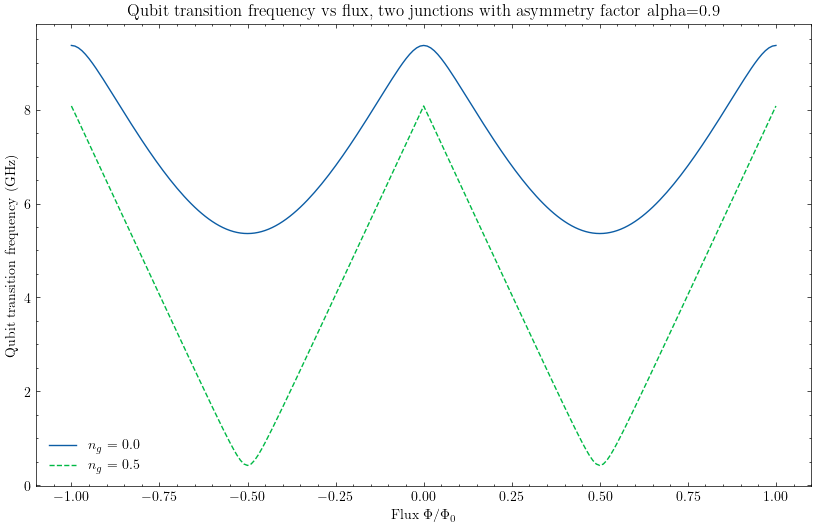

In [61]:
# frequency when alpha=0.9
plt.figure(figsize=(10, 6))

for ng in ng_vals:
    energy, freq = get_spectrum_alpha(t1_pref, t2_pref, ng)
    label = f"$n_g$ = {ng}"
    plt.plot(flux_vals, freq, linestyle='-' if ng==0 else '--', label=f'{label}')

plt.title("Qubit transition frequency vs flux, two junctions with asymmetry factor alpha=0.9")
plt.xlabel("Flux $\\Phi / \\Phi_0$")
plt.ylabel("Qubit transition frequency (GHz)")
plt.legend()
plt.show()

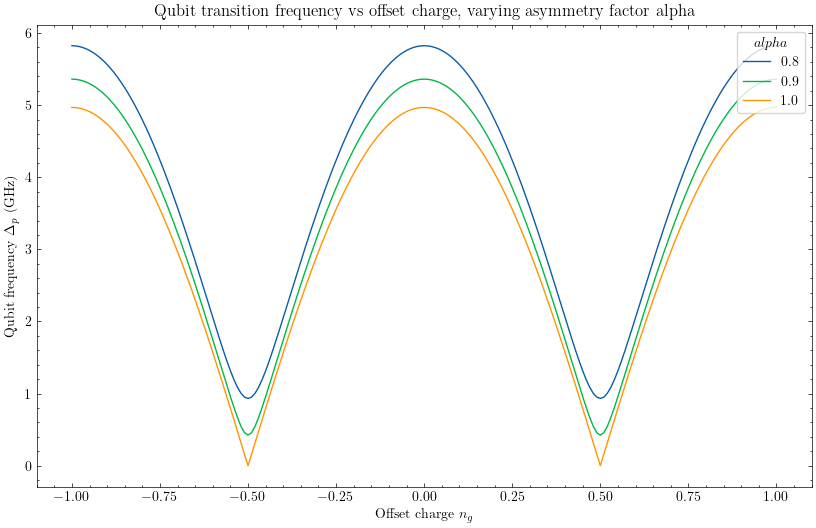

In [62]:
# frequency varying offset charge and alpha
alpha_list = [0.8, 0.9, 1.0]
freq_list_ng_varying_alpha = {}


for alpha in alpha_list: 
    freq_list_ng_varying_alpha[alpha] = []

    # josephson energies
    Ej1 = 10.0
    alpha = alpha
    Ej2 = alpha * Ej1

    # tunneling amplitude prefactors
    t1 = get_tunneling_amplitude(Ej1, Ec)
    t2 = get_tunneling_amplitude(Ej2, Ec)

    # spectrum and frequency
    for ng in ng_list:
        H = get_hamiltonian_alpha(t1, t2, ng, 0.5)
        eigv = np.real(H.eigenenergies())
        freq_list_ng_varying_alpha[alpha].append(eigv[1] - eigv[0])

plt.figure(figsize=(10,6))

plt.xlabel("Offset charge $n_g$")
plt.ylabel("Qubit frequency $\\Delta_p$ (GHz)")
plt.title("Qubit transition frequency vs offset charge, varying asymmetry factor alpha")

for alpha in freq_list_ng_varying_alpha.keys():
    plt.plot(ng_list, freq_list_ng_varying_alpha[alpha], label=alpha)

plt.legend(title='$alpha$', loc='upper right', frameon=True)
plt.show()